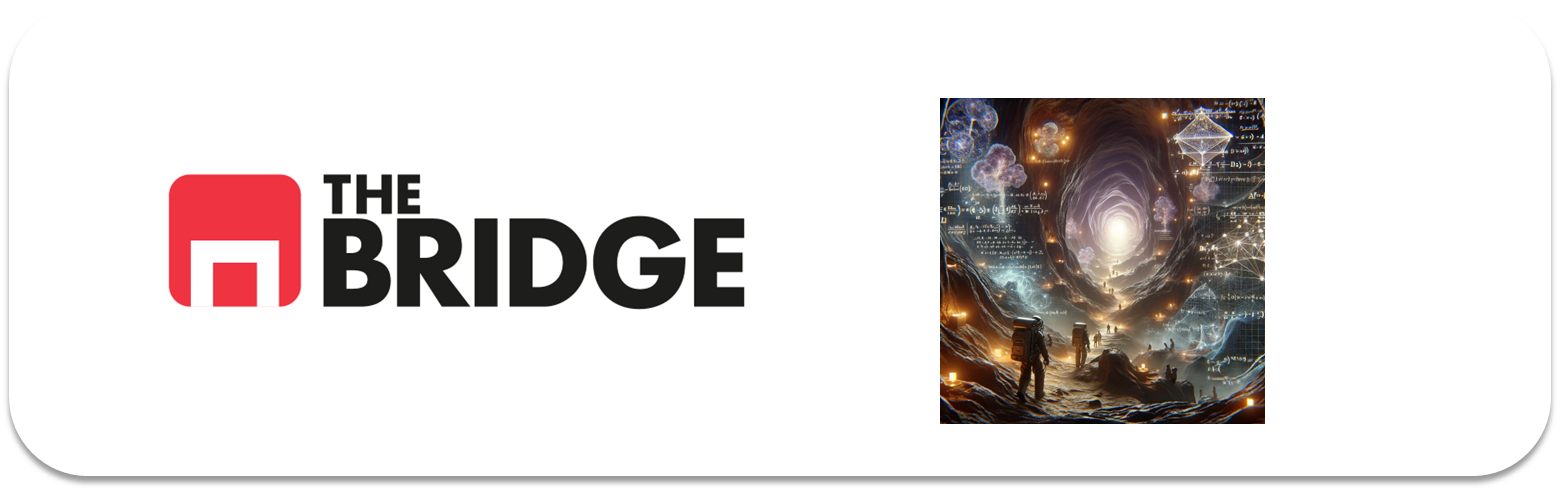

## PRACTICA OBLIGATORIA: **Introducción Keras**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bvt

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import classification_report, confusion_matrix

## Descripción de la práctica

En esta práctica el objetivo es jugar con el framework de [Keras](https://www.tensorflow.org/guide/keras) a partir de la construcción de un modelo DL sobre MLP para clasificar imagenes de ropa como camisetas, zapatos y zapatillas deportivas.

Vamos a utilizar el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imagenes en 10 categorias. Las imagenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles)

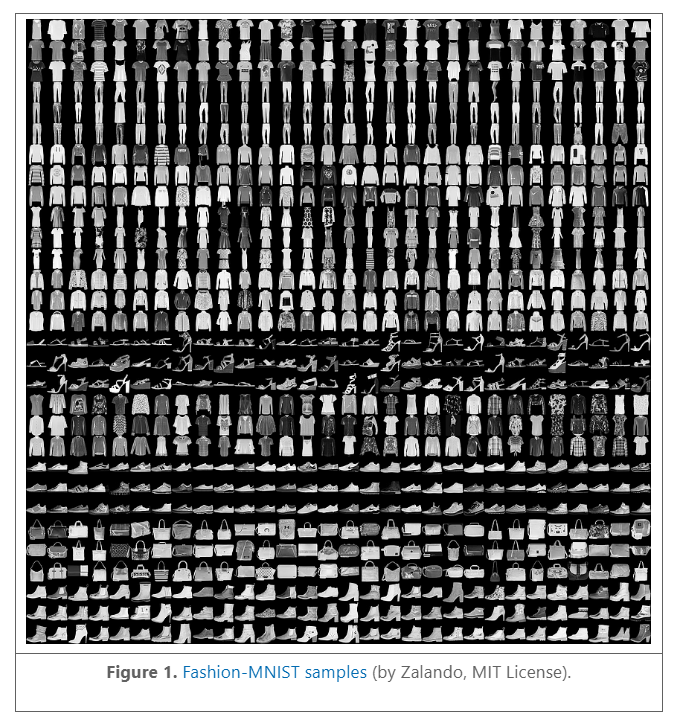

La *class* de ropa que la imagen representa:

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset, es recomendable construirse una lista o un diccionario que permita mapear la clase a el tipo literal.

Se pide:

0. Cargar el dataset desde TensorFlow (tienes una celda ya proporcionada para hacerlo) y visualiza al menos 5 instancias, se recomienda crear una función que permita visualizar subsets de instancias con su etiqueta adecuada. 

1. Construir un modelo DL basado en MLP, es decir una red densa que clasifique las imágenes de ropa. No vas a necesitar más de 1 o 2 capas ocultas. Recuerda que es un problema de clasificación multiclase para configurar correctamente la capa de salida en número de neuronas y función de activiación. Ten en cuenta también que necesitarás utilizar una capa que aplane las imágenes o bien convertir el dataset por tu cuenta.

2. No crees un set de validación, especifica en el entrenamiento que emplee un 20% del dataset en validación. Además muestra gráficamente la evolución en el entrenamiento de la pérdida (loss) por un lado (del conjuto de train y del de validación) y la evolución de la métrica escogida (también de train  y de validación). Razona si es conveniente tener un "callback" de earlystopping, y, en cualquier caso, implementa uno.

3. Finalmente evalua contra test. Muestra el report de clasificación y haz un análisis de los resultados. Para ello, muestra algunas predicciones, el nivel de confianza y si era acertada o no, además muestra la matriz de confusión y analiza en que tipos se confunde más y con que otra clase lo confunde. 

Ejemplo del grafico de predicción más nivel de confianza:

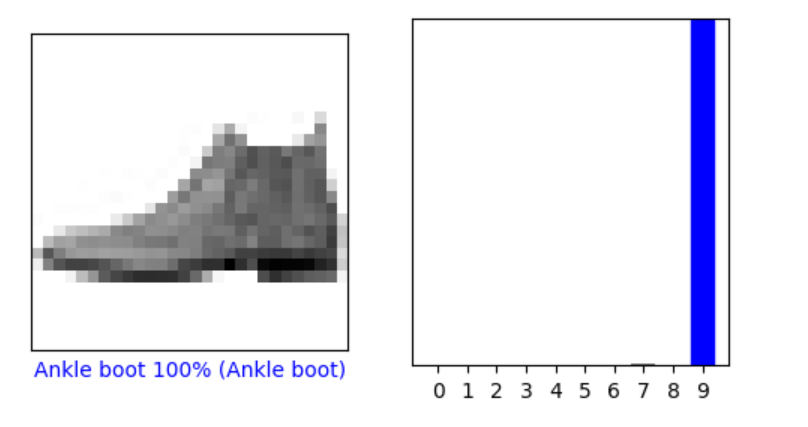

Fíjate que el gráfico de la derecha muestra la probabilidad por clase, de forma que cuanto más alta la probabilidad de la clase elegida más confianza podemos decir que tiene en el resultado. 

**EXTRA**: Como parte extra, obtén los errores de clasificación en los que la confianza del modelo sobre su clasificación errónea supere el 0.7 o 70% (es decir los errores en los que la probabilidad de la clase elegida, equivocadamente, fuera igual o superior a 0.7), de existir muéstralos y analiza si son de alguna clase específica.

```python

# Cargar FASHION_MNIST

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

```

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Diccionario/lista para mapear la etiqueta (0-9) a su nombre
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Train:", train_images.shape, " Test:", test_images.shape)
print("Rango de pixeles:", train_images.min(), "-", train_images.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28)  Test: (10000, 28, 28)
Rango de pixeles: 0 - 255


**Mini-EDA.** Como son imágenes, el EDA útil es: comprobar el rango de píxeles (para normalizar), ver que las **clases están balanceadas** y mirar algunas instancias. Para el reparto de clases usamos el módulo de visualizaciones.

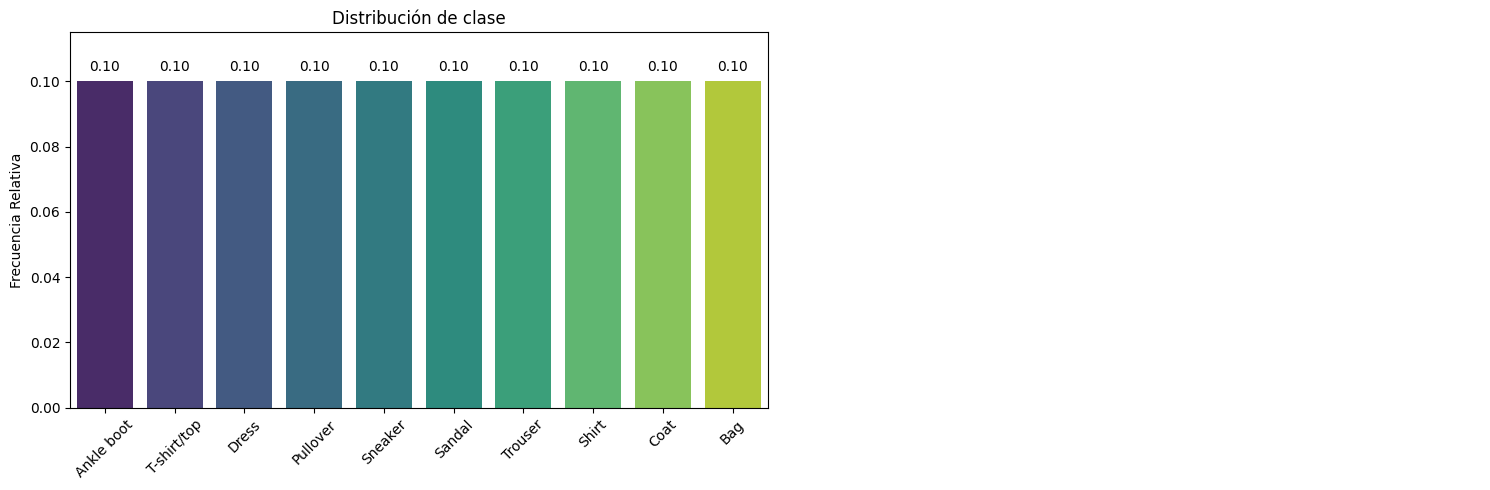

In [3]:
# Reparto de clases con el modulo de visualizaciones (deberia estar balanceado: ~igual por clase)
df_labels = pd.DataFrame({"clase": [class_names[i] for i in train_labels]})
bvt.pinta_distribucion_categoricas(df_labels, ["clase"], relativa=True, mostrar_valores=True)

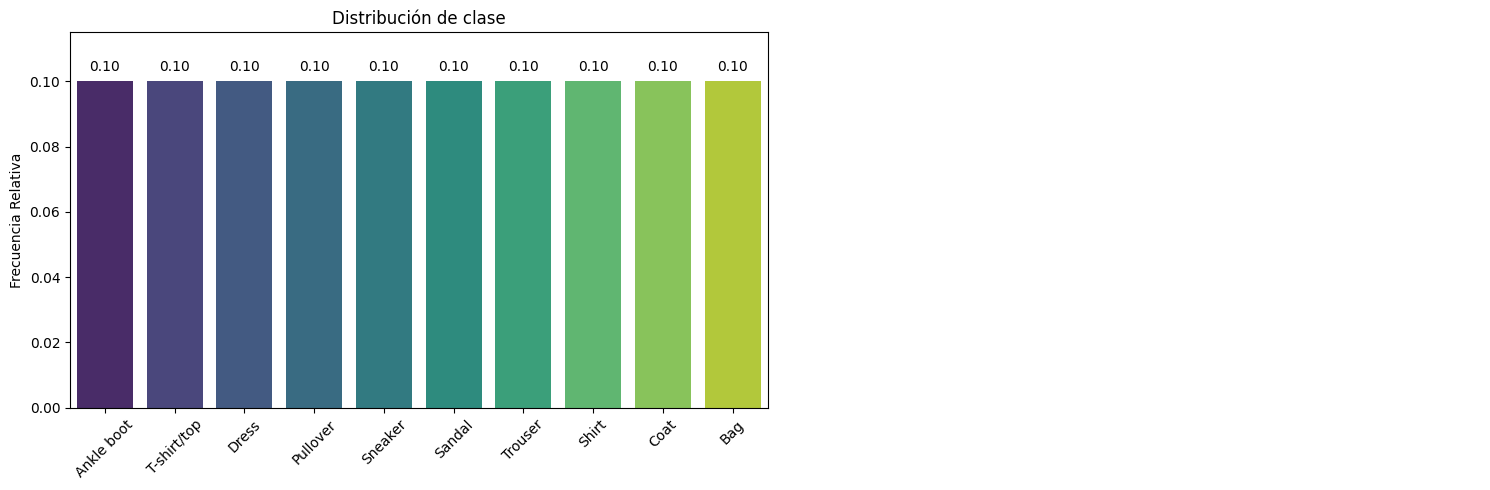

In [4]:
# Reparto de clases con el modulo de visualizaciones (deberia estar balanceado: ~igual por clase)
df_labels = pd.DataFrame({"clase": [class_names[i] for i in train_labels]})
bvt.pinta_distribucion_categoricas(df_labels, ["clase"], relativa=True, mostrar_valores=True)

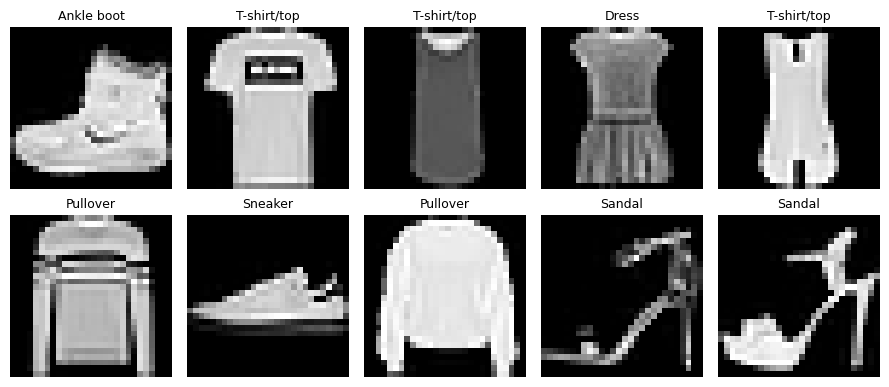

In [5]:
# Funcion para visualizar un subset de instancias con su etiqueta
def mostrar_instancias(imagenes, etiquetas, n=10, predicciones=None, cols=5):
    filas = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 1.8, filas * 2))
    for i in range(n):
        plt.subplot(filas, cols, i + 1)
        plt.imshow(imagenes[i], cmap="gray")
        plt.axis("off")
        if predicciones is None:
            plt.title(class_names[etiquetas[i]], fontsize=9)
        else:
            # etiqueta real vs predicha (para usarla mas adelante)
            color = "green" if predicciones[i] == etiquetas[i] else "red"
            plt.title(f"{class_names[predicciones[i]]}\n(real: {class_names[etiquetas[i]]})",
                      fontsize=8, color=color)
    plt.tight_layout()
    plt.show()

# Visualizamos las primeras 10 instancias de train con su etiqueta
mostrar_instancias(train_images, train_labels, n=10)

**Preparación.** Normalizamos los píxeles a [0, 1] dividiendo entre 255 (ayuda a que la red entrene mejor). No hace falta aplanar a mano: usamos una capa `Flatten` dentro del modelo.

In [6]:
# Normalizamos a [0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

**1. Modelo DL basado en MLP (red densa)**

Una `Flatten` para aplanar los 28×28 a un vector de 784, dos capas ocultas densas con `relu`, y una capa de salida de **10 neuronas con `softmax`** (clasificación multiclase). Como las etiquetas son enteros (0-9), usamos `sparse_categorical_crossentropy` como pérdida y `accuracy` como métrica (clases balanceadas → accuracy es adecuada).

In [7]:
# Construimos el MLP
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),   # entrada 28x28
    keras.layers.Flatten(),               # aplanamos a 784
    keras.layers.Dense(128, activation="relu"),   # capa oculta 1
    keras.layers.Dense(64, activation="relu"),    # capa oculta 2
    keras.layers.Dense(10, activation="softmax"), # salida: 10 clases
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**2. Entrenamiento con validación del 20% y EarlyStopping**

En vez de crear un set de validación aparte, pasamos `validation_split=0.2`. 

**¿Conviene un EarlyStopping?** Sí: al entrenar muchas épocas la red acaba **sobreajustando** (la pérdida de validación empieza a subir mientras la de train sigue bajando). Un EarlyStopping para el entrenamiento cuando la `val_loss` deja de mejorar y, con `restore_best_weights`, se queda con los mejores pesos. Lo implementamos.

In [8]:
# Callback de EarlyStopping sobre la perdida de validacion
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,               # espera 3 epocas sin mejora
    restore_best_weights=True # se queda con los mejores pesos
)

# Entrenamos con 20% de validacion
history = model.fit(
    train_images, train_labels,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8173 - loss: 0.5137 - val_accuracy: 0.8553 - val_loss: 0.3939
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8609 - loss: 0.3790 - val_accuracy: 0.8543 - val_loss: 0.4040
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8759 - loss: 0.3408 - val_accuracy: 0.8697 - val_loss: 0.3618
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8826 - loss: 0.3179 - val_accuracy: 0.8724 - val_loss: 0.3495
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8905 - loss: 0.2964 - val_accuracy: 0.8825 - val_loss: 0.3302
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8950 - loss: 0.2827 - val_accuracy: 0.8706 - val_loss: 0.3524
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8997 - loss: 0.2672 - val_accuracy: 0.8854 - val_loss: 0.3357
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9024 - loss: 0.2585 - 

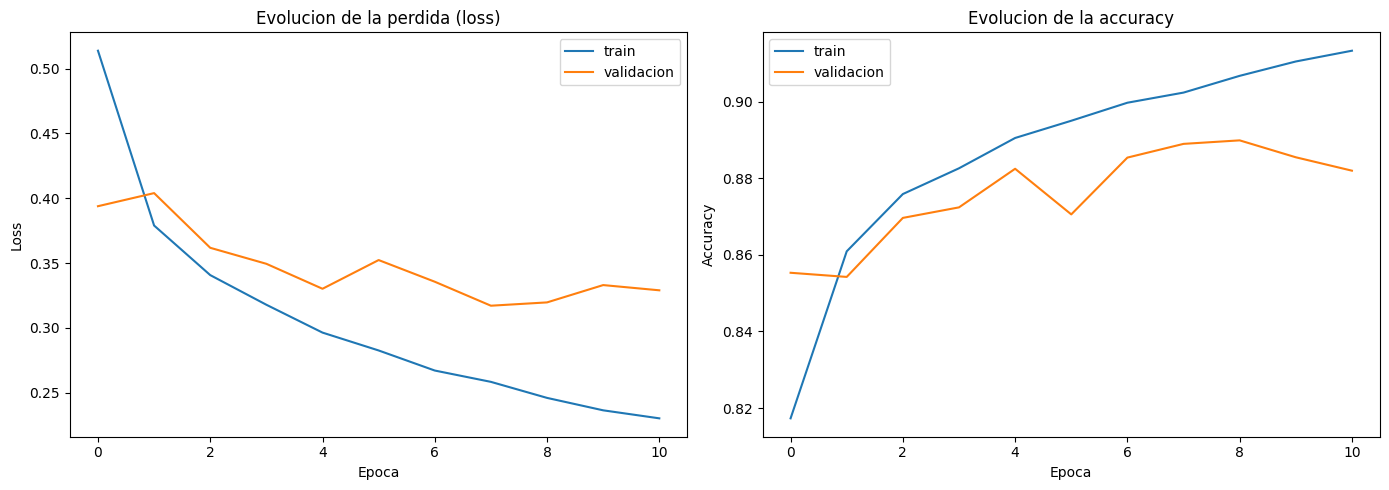

In [9]:
# Evolucion de la perdida y de la metrica (train vs validacion)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validacion")
axes[0].set_title("Evolucion de la perdida (loss)")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="validacion")
axes[1].set_title("Evolucion de la accuracy")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

**3. Evaluación contra test**

In [10]:
# Evaluamos contra el conjunto de test
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print("Accuracy en test:", round(test_acc, 3))

# Predicciones (probabilidades por clase) y clase elegida + confianza
probabilidades = model.predict(test_images, verbose=0)
predicciones = probabilidades.argmax(axis=1)
confianza = probabilidades.max(axis=1)

Accuracy en test: 0.882


In [11]:
# Report de clasificacion
print("Classification report\n")
print(classification_report(test_labels, predicciones,
                            target_names=class_names, zero_division=0))

Classification report

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.85      0.84      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.77      0.81      0.79      1000
       Dress       0.88      0.89      0.88      1000
        Coat       0.82      0.75      0.79      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.71      0.70      0.70      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



**Predicciones con nivel de confianza**

Replicamos el gráfico del enunciado: a la izquierda la imagen con la predicción (verde si acierta, rojo si falla) y su % de confianza; a la derecha las probabilidades por clase.

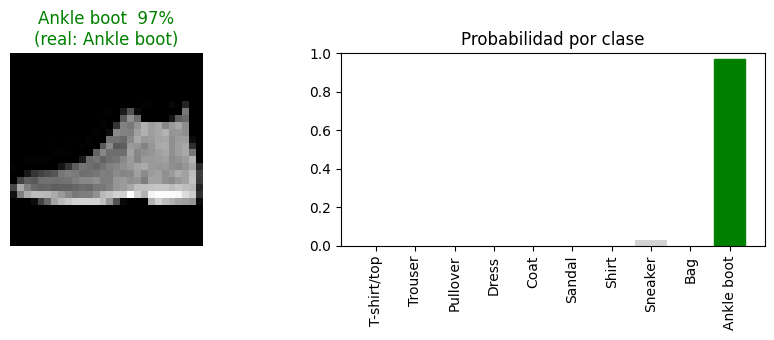

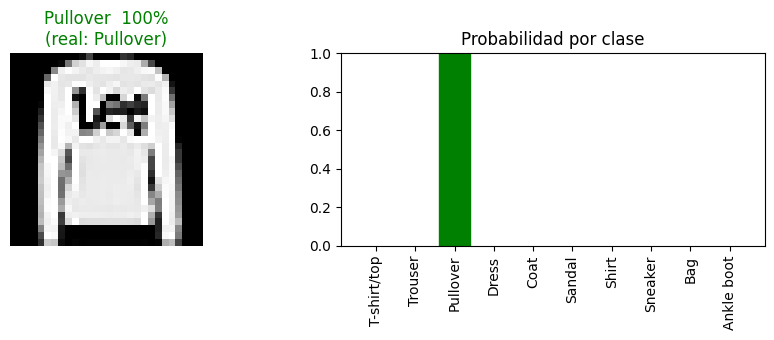

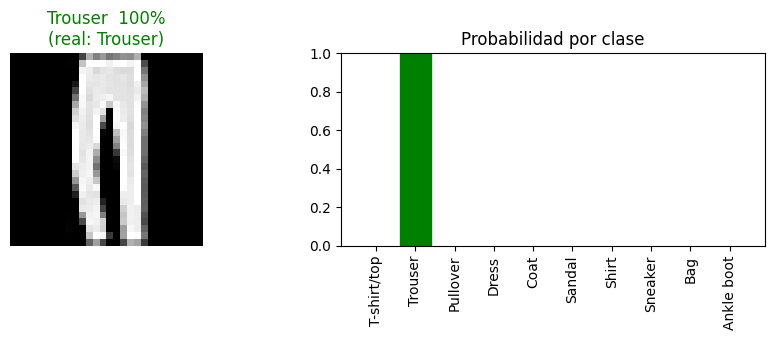

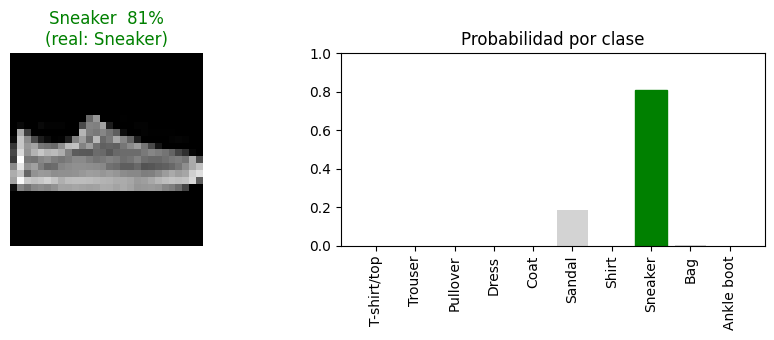

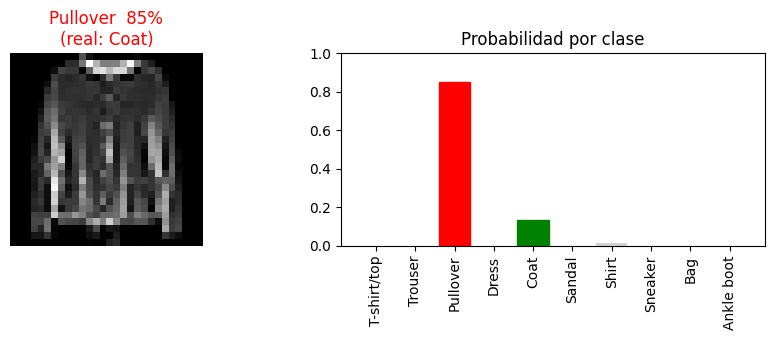

In [12]:
# Funcion tipo la del enunciado: imagen + barras de probabilidad por clase
def plot_prediccion(i, probabilidades, etiquetas_reales, imagenes):
    probs = probabilidades[i]
    pred = probs.argmax()
    real = etiquetas_reales[i]
    color = "green" if pred == real else "red"

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(9, 3.5))

    # Izquierda: imagen + prediccion y confianza
    ax_img.imshow(imagenes[i], cmap="gray")
    ax_img.axis("off")
    ax_img.set_title(f"{class_names[pred]}  {100*probs[pred]:.0f}%\n(real: {class_names[real]})",
                     color=color)

    # Derecha: probabilidad por clase
    barras = ax_bar.bar(range(10), probs, color="lightgray")
    barras[pred].set_color(color)      # la clase elegida
    barras[real].set_color("green")    # la clase real (si coincide, queda verde)
    ax_bar.set_xticks(range(10))
    ax_bar.set_xticklabels(class_names, rotation=90)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_title("Probabilidad por clase")

    plt.tight_layout()
    plt.show()

# Mostramos unas cuantas predicciones (mezcla de aciertos y fallos)
for i in [0, 1, 2, 12, 25]:
    plot_prediccion(i, probabilidades, test_labels, test_images)

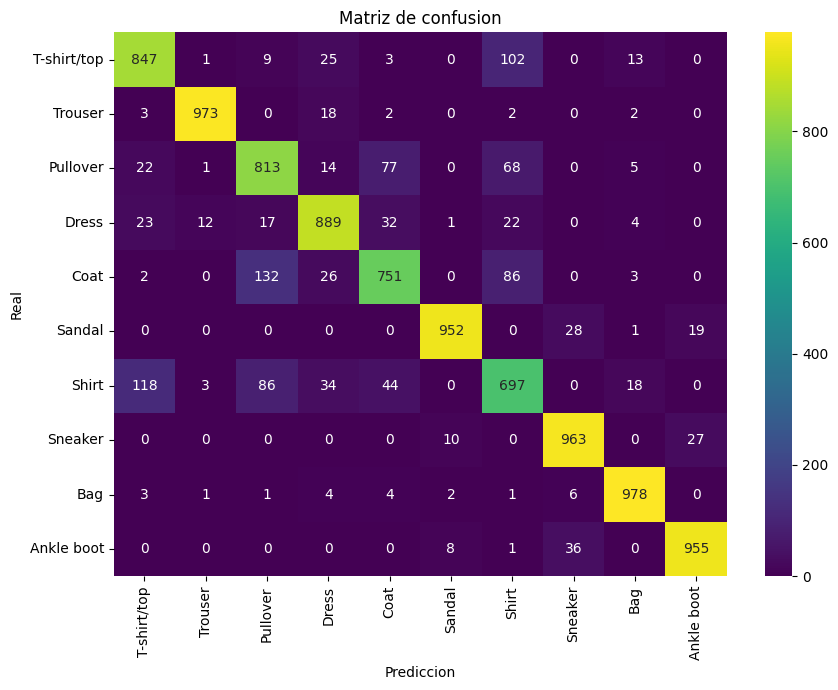

In [13]:
# Matriz de confusion
cm = confusion_matrix(test_labels, predicciones)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion")
plt.tight_layout()
plt.show()

In [14]:
# Para analizar: en que clase se equivoca mas y con cual la confunde
cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

print("Confusiones mas frecuentes (real -> predicha):\n")
# Top 5 pares de confusion
indices = np.dstack(np.unravel_index(np.argsort(cm_sin_diagonal.ravel())[::-1],
                                     cm_sin_diagonal.shape))[0]
for real, pred in indices[:5]:
    print(f"  {class_names[real]:>12}  ->  {class_names[pred]:<12}  ({cm[real, pred]} veces)")

Confusiones mas frecuentes (real -> predicha):

          Coat  ->  Pullover      (132 veces)
         Shirt  ->  T-shirt/top   (118 veces)
   T-shirt/top  ->  Shirt         (102 veces)
          Coat  ->  Shirt         (86 veces)
         Shirt  ->  Pullover      (86 veces)


**Análisis:**

Los mayores errores están entre prendas de torso parecidas: `Shirt` (camisa) se confunde mucho con `T-shirt/top`, `Pullover` y `Coat`, quizá porque a 28×28 y en gris son visualmente muy similares. El calzado (`Sandal`, `Sneaker`, `Ankle boot`) y `Trouser`/`Bag` se clasifican mucho mejor porque su silueta es más distintiva. La clase `Shirt` es la de peor recall.

**EXTRA — Errores con confianza ≥ 0.7**

Buscamos los casos en los que el modelo se equivocó **pero estaba muy seguro** (probabilidad de la clase elegida ≥ 0.7). Son los errores "peligrosos": el modelo falla con convicción.

Errores totales: 1182
Errores con confianza >= 0.7: 534

Reparto por clase real de los errores muy confiados:
clase_real
Shirt          147
Coat           111
Pullover        63
T-shirt/top     63
Sandal          39
Ankle boot      31
Dress           31
Sneaker         25
Trouser         13
Bag             11
Name: count, dtype: int64


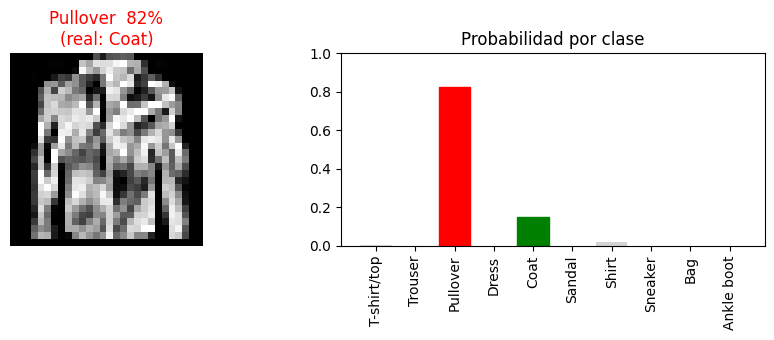

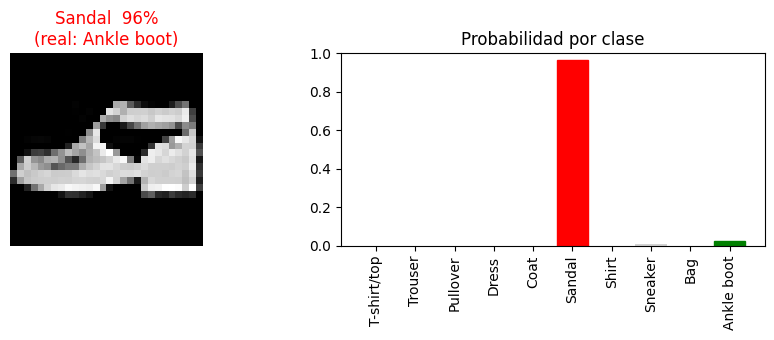

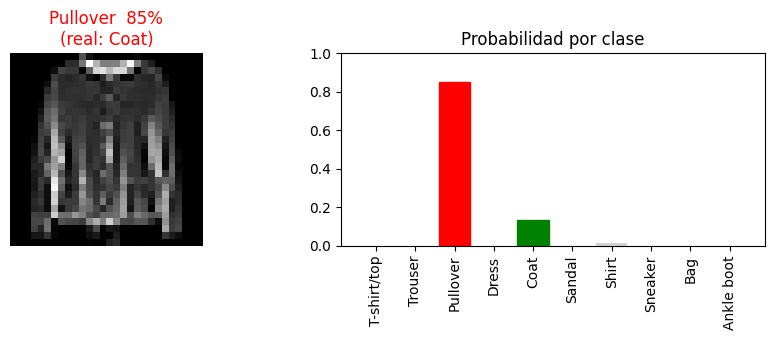

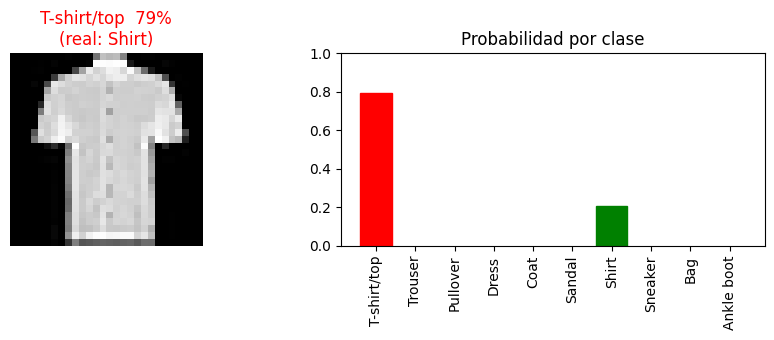

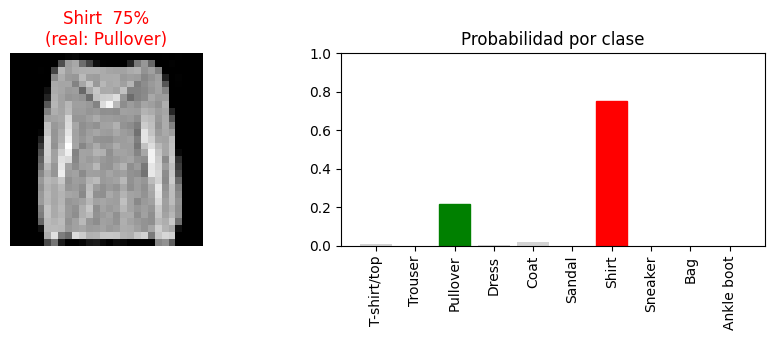

In [15]:
# Errores en los que la confianza de la clase (erronea) elegida es >= 0.7
errores = predicciones != test_labels
alta_confianza = errores & (confianza >= 0.7)

n_alta = alta_confianza.sum()
print("Errores totales:", errores.sum())
print("Errores con confianza >= 0.7:", n_alta)

if n_alta > 0:
    idx_alta = np.where(alta_confianza)[0]

    # De que clase REAL son esos errores y por que clase los confunde
    reales = test_labels[idx_alta]
    predichas = predicciones[idx_alta]

    resumen = pd.DataFrame({
        "clase_real": [class_names[r] for r in reales],
        "clase_predicha": [class_names[p] for p in predichas],
    })
    print("\nReparto por clase real de los errores muy confiados:")
    print(resumen["clase_real"].value_counts())

    # Mostramos algunos
    for i in idx_alta[:5]:
        plot_prediccion(i, probabilidades, test_labels, test_images)
else:
    print("No hay errores con confianza >= 0.7")

**Comentario del extra:**

Los errores muy confiados (≥ 0.7) suelen concentrarse en las clases que ya salían en la matriz de confusión: sobre todo `Shirt` confundida con `T-shirt/top` o `Pullover`. Si hubiera que mejorar el modelo, esas clases de torso serían el objetivo prioritario.